In [88]:
from sklearn.datasets import make_regression
import numpy as np

In [89]:
X, y = make_regression(n_samples=20, n_features=1, n_targets=1, n_informative=1, noise=80, random_state=20)

In [90]:
!pip install matplotlib

# plt.scatter(X, y)

In [91]:
import matplotlib.pyplot as plt

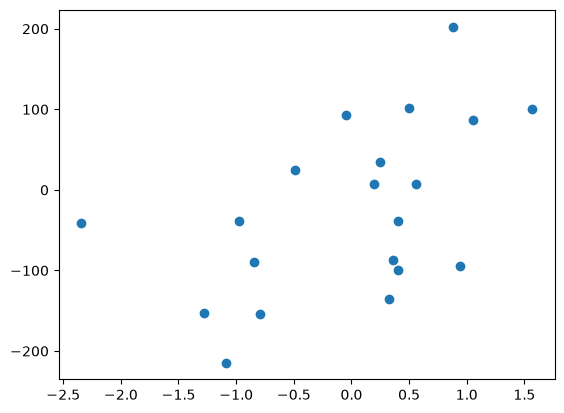

In [92]:
plt.scatter(X, y)

In [93]:
from sklearn.linear_model import LinearRegression


In [94]:
model = LinearRegression()

In [95]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [96]:
slope = model.coef_
bias = model.intercept_

In [97]:
print(slope)
print(bias)

[58.22583203]
-23.013294111758725


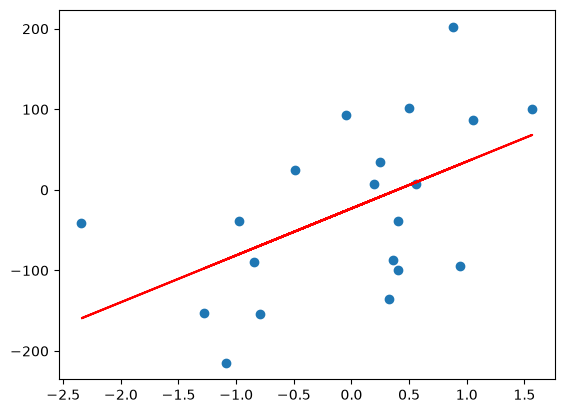

In [98]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')

In [99]:
# now let's fix the slope as m = 58.22 and will perform the gradient descent on our data
# by assuming the value of b = 0
y_pred = ((58.22 * X) + 0).reshape(20)

In [100]:
y_pred.shape

(20,)

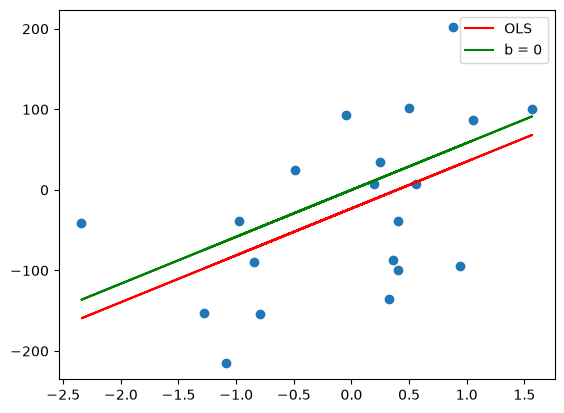

In [101]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', label = 'OLS')
plt.plot(X, y_pred, color='green', label='b = 0')
plt.legend()

In [102]:
# calculating loss_slope
m = 58.22
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(920.5366378477736)

In [103]:
# now let's take learning rate = 0.1

lr = 0.01

step_size = loss_slope * lr
step_size

np.float64(9.205366378477736)

In [104]:
# now calculate the new intercept

b = b - step_size
b

np.float64(-9.205366378477736)

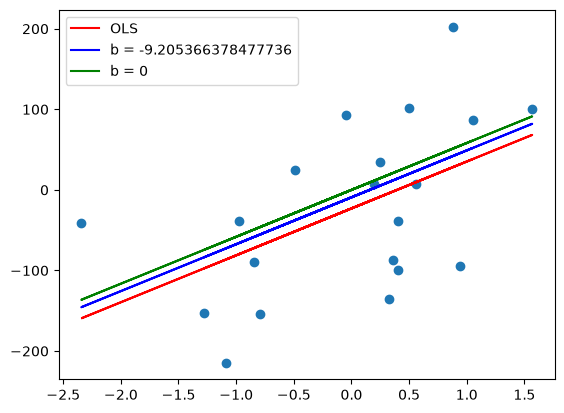

In [105]:
y_pred1 = ((58.22 * X) + b).reshape(20)

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', label = 'OLS')
plt.plot(X, y_pred1, color='blue', label='b = {}'.format(b))
plt.plot(X, y_pred, color='green', label='b = 0')
plt.legend()

In [106]:
# 2nd iteration

m = 58.22

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(552.3219827086639)

In [107]:
lr = 0.01

step_size = loss_slope * lr
step_size

np.float64(5.523219827086639)

In [108]:
b = b - step_size
b


np.float64(-14.728586205564376)

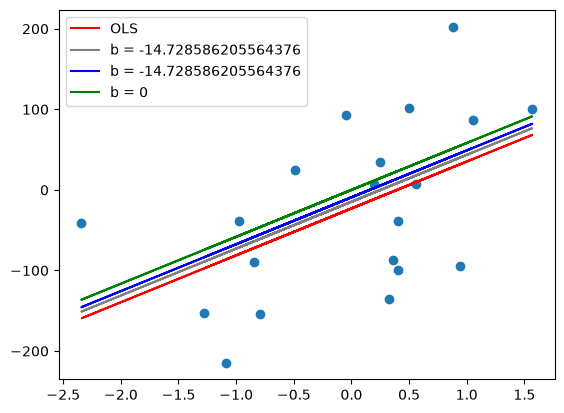

In [109]:
y_pred2 = ((58.22 * X) + b).reshape(20)

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', label = 'OLS')
plt.plot(X, y_pred2, color='grey', label='b = {}'.format(b))
plt.plot(X, y_pred1, color='blue', label='b = {}'.format(b))
plt.plot(X, y_pred, color='green', label='b = 0')
plt.legend()

In [110]:
# 3rd iteration
m = 58.22

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(331.39318962519854)

In [111]:
lr = 0.01

step_size = loss_slope * lr
step_size

np.float64(3.3139318962519857)

In [112]:
b = b - step_size
b


np.float64(-18.042518101816363)

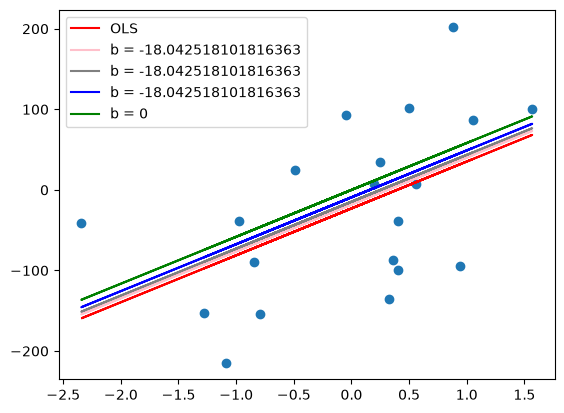

In [113]:
y_pred3 = ((58.22 * X) + b).reshape(20)

plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red', label = 'OLS')
plt.plot(X, y_pred3, color="pink", label='b = {}'.format(b))
plt.plot(X, y_pred2, color='grey', label='b = {}'.format(b))
plt.plot(X, y_pred1, color='blue', label='b = {}'.format(b))
plt.plot(X, y_pred, color='green', label='b = 0')
plt.legend()

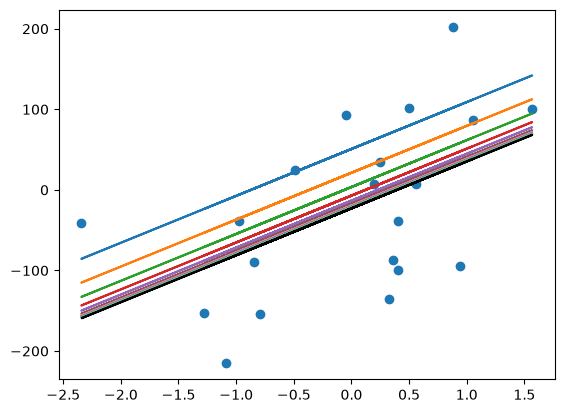

In [124]:
# now we run inside a loop 

b = 100 # random
m = 58.22 # slope
lr = 0.01 # learning rate

epochs = 10 # iterations

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - (lr * loss_slope)

    y_pred = m * X + b

    plt.plot(X, y_pred)
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='black') # OLS



